In [20]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [21]:
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
NVIDIA_BASE_URL= "https://integrate.api.nvidia.com/v1"
load_dotenv(override=True)
meta_api_key = os.getenv("META_API_KEY")
google_api_key = os.getenv('GOOGLE_API_KEY')
gemini = OpenAI(base_url=GEMINI_BASE_URL, api_key=google_api_key)
meta = OpenAI(base_url = NVIDIA_BASE_URL, api_key = meta_api_key)
MODEL="gemini-2.5-flash"

DB = "prices.db"

In [22]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [23]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [24]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [25]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [ ]:

def chat(message, history):
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

In [26]:
def chat(message, history):
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [27]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

In [ ]:
import base64
import wave
from io import BytesIO
from PIL import Image
import numpy as np
from google import genai as google_genai
from google.genai import types as genai_types

In [29]:
def artist(city):
    image_response = gemini.images.generate(
            model="gemini-2.5-flash-image",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
            response_format="b64_json",
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

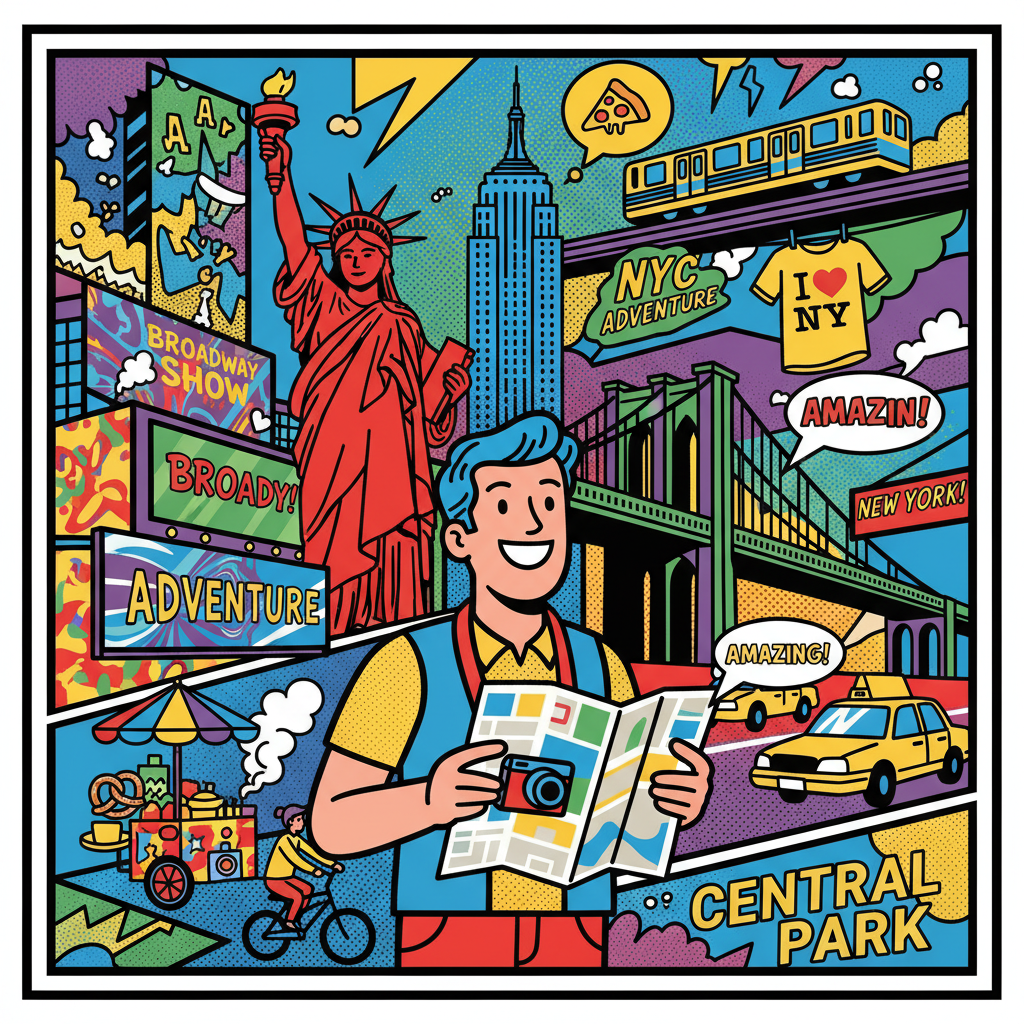

In [15]:
image = artist("New York City")
display(image)

In [54]:
import wave

def talker(message):
    client = google_genai.Client(api_key=google_api_key)
    pcm = b""
    for chunk in client.models.generate_content_stream(
        model="gemini-2.5-flash-preview-tts",
        contents=message,
        config=genai_types.GenerateContentConfig(
            response_modalities=["AUDIO"],
            speech_config=genai_types.SpeechConfig(
                voice_config=genai_types.VoiceConfig(
                    prebuilt_voice_config=genai_types.PrebuiltVoiceConfig(voice_name="Aoede")
                )
            ),
        ),
    ):
        if chunk.candidates and chunk.candidates[0].content:
            pcm += chunk.candidates[0].content.parts[0].inline_data.data

    print(f"TALKER: pcm bytes = {len(pcm)}", flush=True)

    buf = BytesIO()
    with wave.open(buf, "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(24000)
        wf.writeframes(pcm)
    return buf.getvalue()

In [55]:
def chat(history):
    messages = [{"role": "system", "content": system_message}] + history
    response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    if cities:
        image = artist(cities[0])

    yield history, None, image       # clear audio so the next yield is seen as a new value
    voice = talker(reply)
    yield history, voice, image

In [56]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [57]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

/var/folders/vs/47zd34_d7yq9_bqfx2tjt63h0000gn/T/ipykernel_28183/856743599.py:10: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=500, type="messages")


* Running on local URL:  http://127.0.0.1:7872
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for london


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


TALKER: pcm bytes = 190606
DATABASE TOOL CALLED: Getting price for Tokyo


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


TALKER: pcm bytes = 221326
